In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import Lasso, Ridge
import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import LearningCurveDisplay
from sklearn.metrics import log_loss
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer = fetch_ucirepo(id=17)

# metadata
print(breast_cancer.metadata)

# variable information
print(breast_cancer.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [4]:
df = pd.DataFrame(breast_cancer.data.features)
df['diagnosis'] = pd.DataFrame(breast_cancer.data.targets)

In [5]:
rename_dict = {
    # Mean features (variablename1 -> variablename_mean)
    'radius1': 'radius_mean',
    'texture1': 'texture_mean',
    'perimeter1': 'perimeter_mean',
    'area1': 'area_mean',
    'smoothness1': 'smoothness_mean',
    'compactness1': 'compactness_mean',
    'concavity1': 'concavity_mean',
    'concave_points1': 'concave_points_mean',
    'symmetry1': 'symmetry_mean',
    'fractal_dimension1': 'fractal_dimension_mean',

    # Standard Error features (variablename2 -> variablename_se)
    'radius2': 'radius_se',
    'texture2': 'texture_se',
    'perimeter2': 'perimeter_se',
    'area2': 'area_se',
    'smoothness2': 'smoothness_se',
    'compactness2': 'compactness_se',
    'concavity2': 'concavity_se',
    'concave_points2': 'concave_points_se',
    'symmetry2': 'symmetry_se',
    'fractal_dimension2': 'fractal_dimension_se',

    # Worst features (variablename3 -> variablename_worst)
    'radius3': 'radius_worst',
    'texture3': 'texture_worst',
    'perimeter3': 'perimeter_worst',
    'area3': 'area_worst',
    'smoothness3': 'smoothness_worst',
    'compactness3': 'compactness_worst',
    'concavity3': 'concavity_worst',
    'concave_points3': 'concave_points_worst',
    'symmetry3': 'symmetry_worst',
    'fractal_dimension3': 'fractal_dimension_worst',
}

# Apply renaming
df = df.rename(columns=rename_dict)

In [6]:
df.shape

(569, 31)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave_points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            5

In [8]:
df['diagnosis'] = np.where(df['diagnosis'] == 'M', 1, 0)

In [9]:
y = df['diagnosis']
X = df.drop(['diagnosis'], axis=1)

In [10]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

# EDA: Exploratory Data Analysis

### Variable Definitions and Medical Significance:

* **Radius**: The average distance from the centre to points on the cell nucleus perimeter. Cancerous cells typically exhibit larger nuclei than healthy ones.
* **Texture**: A measure of grey-scale variation within the pixels. It describes whether the cell nucleus surface appears smooth or coarse.
* **Perimeter**: The total length of the boundary surrounding the cell nucleus.
* **Area**: The total surface area of the cell nucleus. This is a vital indicator, as malignant cells often expand significantly.
* **Smoothness**: While benign cells are usually rounded and smooth, malignant cells often feature sharp edges or irregular protrusions.
* **Compactness**: Indicates how "neat" or condensed the cell shape is. Cancerous cells often appear elongated or structurally complex.
* **Concavity**: Measures the severity of indentations on the nuclear contour. Deep concavities are often a red flag for abnormal growth.
* **Concave Points**: A count of the indented portions of the boundary. A higher number of concave points suggests a more distorted nucleus.
* **Symmetry**: Measures whether the two halves of the nucleus match. Cancerous cells tend to grow unevenly, leading to a loss of symmetry.
* **Fractal Dimension**: A mathematical index describing boundary complexity. The more "rugged" or jagged the boundary, the higher this value.

---

### Data Variations


Each of the features above is recorded in three variations:

1.  **Mean**: The average value across all observed cells in the biopsy sample, providing a general overview of the tumour.
2.  **SE (Standard Error)**: Measures the variation between cells. For instance, a high `radius_se` suggests a non-uniform tumour containing both very large and small cells.
3.  **Worst**: Represents the "worst-case" or maximum value recorded for that feature. In a clinical context, this is often the most critical metric, as specialists focus on the most severely mutated cells to confirm a malignancy.


In [12]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [13]:
df[df["diagnosis"] == 1].describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.0
mean,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,0.609083,1.210915,4.323929,72.672406,0.006780,0.032281,0.041824,0.015060,0.020472,0.004062,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530,1.0
std,3.203971,3.779470,21.854653,367.937978,0.012608,0.053987,0.075019,0.034374,0.027638,0.007573,0.345039,0.483178,2.568546,61.355268,0.002890,0.018387,0.021603,0.005517,0.010065,0.002041,4.283569,5.434804,29.457055,597.967743,0.021870,0.170372,0.181507,0.046308,0.074685,0.021553,0.0
min,10.950000,10.380000,71.900000,361.600000,0.073710,0.046050,0.023980,0.020310,0.130800,0.049960,0.193800,0.362100,1.334000,13.990000,0.002667,0.008422,0.011010,0.005174,0.007882,0.001087,12.840000,16.670000,85.100000,508.100000,0.088220,0.051310,0.023980,0.028990,0.156500,0.055040,1.0
25%,15.075000,19.327500,98.745000,705.300000,0.094010,0.109600,0.109525,0.064620,0.174050,0.056598,0.390375,0.892825,2.715500,35.762500,0.005085,0.019662,0.026998,0.011415,0.014615,0.002688,17.730000,25.782500,119.325000,970.300000,0.130475,0.244475,0.326425,0.152750,0.276500,0.076302,1.0
50%,17.325000,21.460000,114.200000,932.000000,0.102200,0.132350,0.151350,0.086280,0.189900,0.061575,0.547200,1.102500,3.679500,58.455000,0.006209,0.028590,0.037125,0.014205,0.017700,0.003739,20.590000,28.945000,138.000000,1303.000000,0.143450,0.356350,0.404900,0.182000,0.310300,0.087600,1.0
75%,19.590000,23.765000,129.925000,1203.750000,0.110925,0.172400,0.203050,0.103175,0.209850,0.067075,0.757300,1.429250,5.206250,94.000000,0.007971,0.038910,0.050443,0.017497,0.022132,0.004892,23.807500,32.690000,159.800000,1712.750000,0.155975,0.447850,0.556175,0.210675,0.359225,0.102625,1.0
max,28.110000,39.280000,188.500000,2501.000000,0.144700,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,3.568000,21.980000,542.200000,0.031130,0.135400,0.143800,0.040900,0.078950,0.012840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.170000,0.291000,0.663800,0.207500,1.0


In [14]:
df[df["diagnosis"] == 0].describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
count,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.00000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.0
mean,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,0.284082,1.22038,2.000321,21.135148,0.007196,0.021438,0.025997,0.009858,0.020584,0.003636,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442,0.0
std,1.780512,3.995125,11.807438,134.287118,0.013446,0.033750,0.043442,0.015909,0.024807,0.006747,0.112570,0.58918,0.771169,8.843472,0.003061,0.016352,0.032918,0.005709,0.006999,0.002938,1.981368,5.493955,13.527091,163.601424,0.020013,0.092180,0.140368,0.035797,0.041745,0.013804,0.0
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.051850,0.111500,0.36020,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.009539,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156600,0.055210,0.0
25%,11.080000,15.150000,70.870000,378.200000,0.083060,0.055620,0.020310,0.015020,0.158000,0.058530,0.207300,0.79590,1.445000,15.260000,0.005212,0.011320,0.010990,0.006433,0.015600,0.002074,12.080000,19.580000,78.270000,447.100000,0.110400,0.112000,0.077080,0.051040,0.240600,0.070090,0.0
50%,12.200000,17.390000,78.180000,458.400000,0.090760,0.075290,0.037090,0.023440,0.171400,0.061540,0.257500,1.10800,1.851000,19.630000,0.006530,0.016310,0.018400,0.009061,0.019090,0.002808,13.350000,22.820000,86.920000,547.400000,0.125400,0.169800,0.141200,0.074310,0.268700,0.077120,0.0
75%,13.370000,19.760000,86.100000,551.100000,0.100700,0.097550,0.059990,0.032510,0.189000,0.065760,0.341600,1.49200,2.388000,25.030000,0.008534,0.025890,0.030560,0.011870,0.024060,0.004174,14.800000,26.510000,96.590000,670.000000,0.137600,0.230200,0.221600,0.097490,0.298300,0.085410,0.0
max,17.850000,33.810000,114.600000,992.100000,0.163400,0.223900,0.410800,0.085340,0.274300,0.095750,0.881100,4.88500,5.118000,77.110000,0.021770,0.106400,0.396000,0.052790,0.061460,0.029840,19.820000,41.780000,127.100000,1210.000000,0.200600,0.584900,1.252000,0.175000,0.422800,0.148600,0.0


In [15]:
for column in X.columns:
    max_value = X[column].max()
    max_index = X[column].idxmax() # return row have the max value
    corresponding_diagnosis = df.loc[max_index, 'diagnosis']
    print(f"{column} have the max value = {max_value:4f}, Diagnosis: {corresponding_diagnosis}")

radius_mean have the max value = 28.110000, Diagnosis: 1
texture_mean have the max value = 39.280000, Diagnosis: 1
perimeter_mean have the max value = 188.500000, Diagnosis: 1
area_mean have the max value = 2501.000000, Diagnosis: 1
smoothness_mean have the max value = 0.163400, Diagnosis: 0
compactness_mean have the max value = 0.345400, Diagnosis: 1
concavity_mean have the max value = 0.426800, Diagnosis: 1
concave_points_mean have the max value = 0.201200, Diagnosis: 1
symmetry_mean have the max value = 0.304000, Diagnosis: 1
fractal_dimension_mean have the max value = 0.097440, Diagnosis: 1
radius_se have the max value = 2.873000, Diagnosis: 1
texture_se have the max value = 4.885000, Diagnosis: 0
perimeter_se have the max value = 21.980000, Diagnosis: 1
area_se have the max value = 542.200000, Diagnosis: 1
smoothness_se have the max value = 0.031130, Diagnosis: 1
compactness_se have the max value = 0.135400, Diagnosis: 1
concavity_se have the max value = 0.396000, Diagnosis: 0
con

In [16]:
for column in X.columns:
    min_value = X[column].min()
    min_index = X[column].idxmin() # return row have the min value
    corresponding_diagnosis = df.loc[min_index, 'diagnosis']
    print(f"{column} have the min value = {min_value:4f}, Diagnosis: {corresponding_diagnosis}")

radius_mean have the min value = 6.981000, Diagnosis: 0
texture_mean have the min value = 9.710000, Diagnosis: 0
perimeter_mean have the min value = 43.790000, Diagnosis: 0
area_mean have the min value = 143.500000, Diagnosis: 0
smoothness_mean have the min value = 0.052630, Diagnosis: 0
compactness_mean have the min value = 0.019380, Diagnosis: 0
concavity_mean have the min value = 0.000000, Diagnosis: 0
concave_points_mean have the min value = 0.000000, Diagnosis: 0
symmetry_mean have the min value = 0.106000, Diagnosis: 0
fractal_dimension_mean have the min value = 0.049960, Diagnosis: 1
radius_se have the min value = 0.111500, Diagnosis: 0
texture_se have the min value = 0.360200, Diagnosis: 0
perimeter_se have the min value = 0.757000, Diagnosis: 0
area_se have the min value = 6.802000, Diagnosis: 0
smoothness_se have the min value = 0.001713, Diagnosis: 0
compactness_se have the min value = 0.002252, Diagnosis: 0
concavity_se have the min value = 0.000000, Diagnosis: 0
concave_po

In [17]:
df.isnull().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
diagnosis                  0
dtype: int64

diagnosis
0    357
1    212
Name: count, dtype: int64


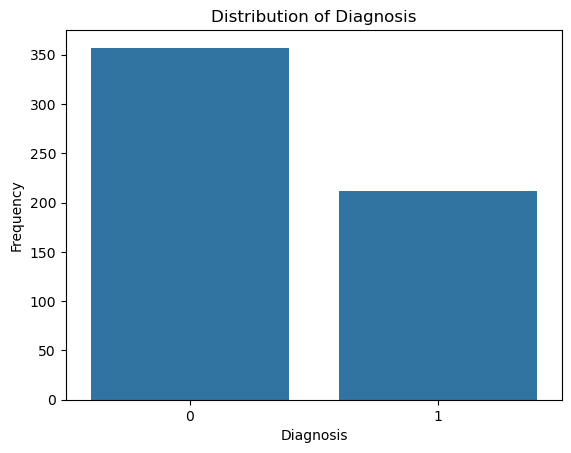

In [18]:
print(y.value_counts())
sns.countplot(x=y)
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Frequency')
plt.show()


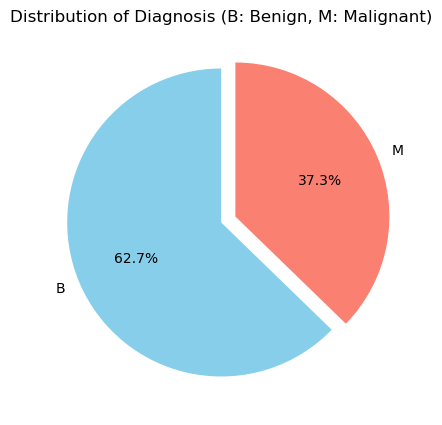

In [19]:
plt.figure(figsize=(5, 5))
plt.pie(y.value_counts(), explode= [0,0.1], labels= ["B", "M" ], colors= ['skyblue','salmon'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Diagnosis (B: Benign, M: Malignant)')
plt.show()

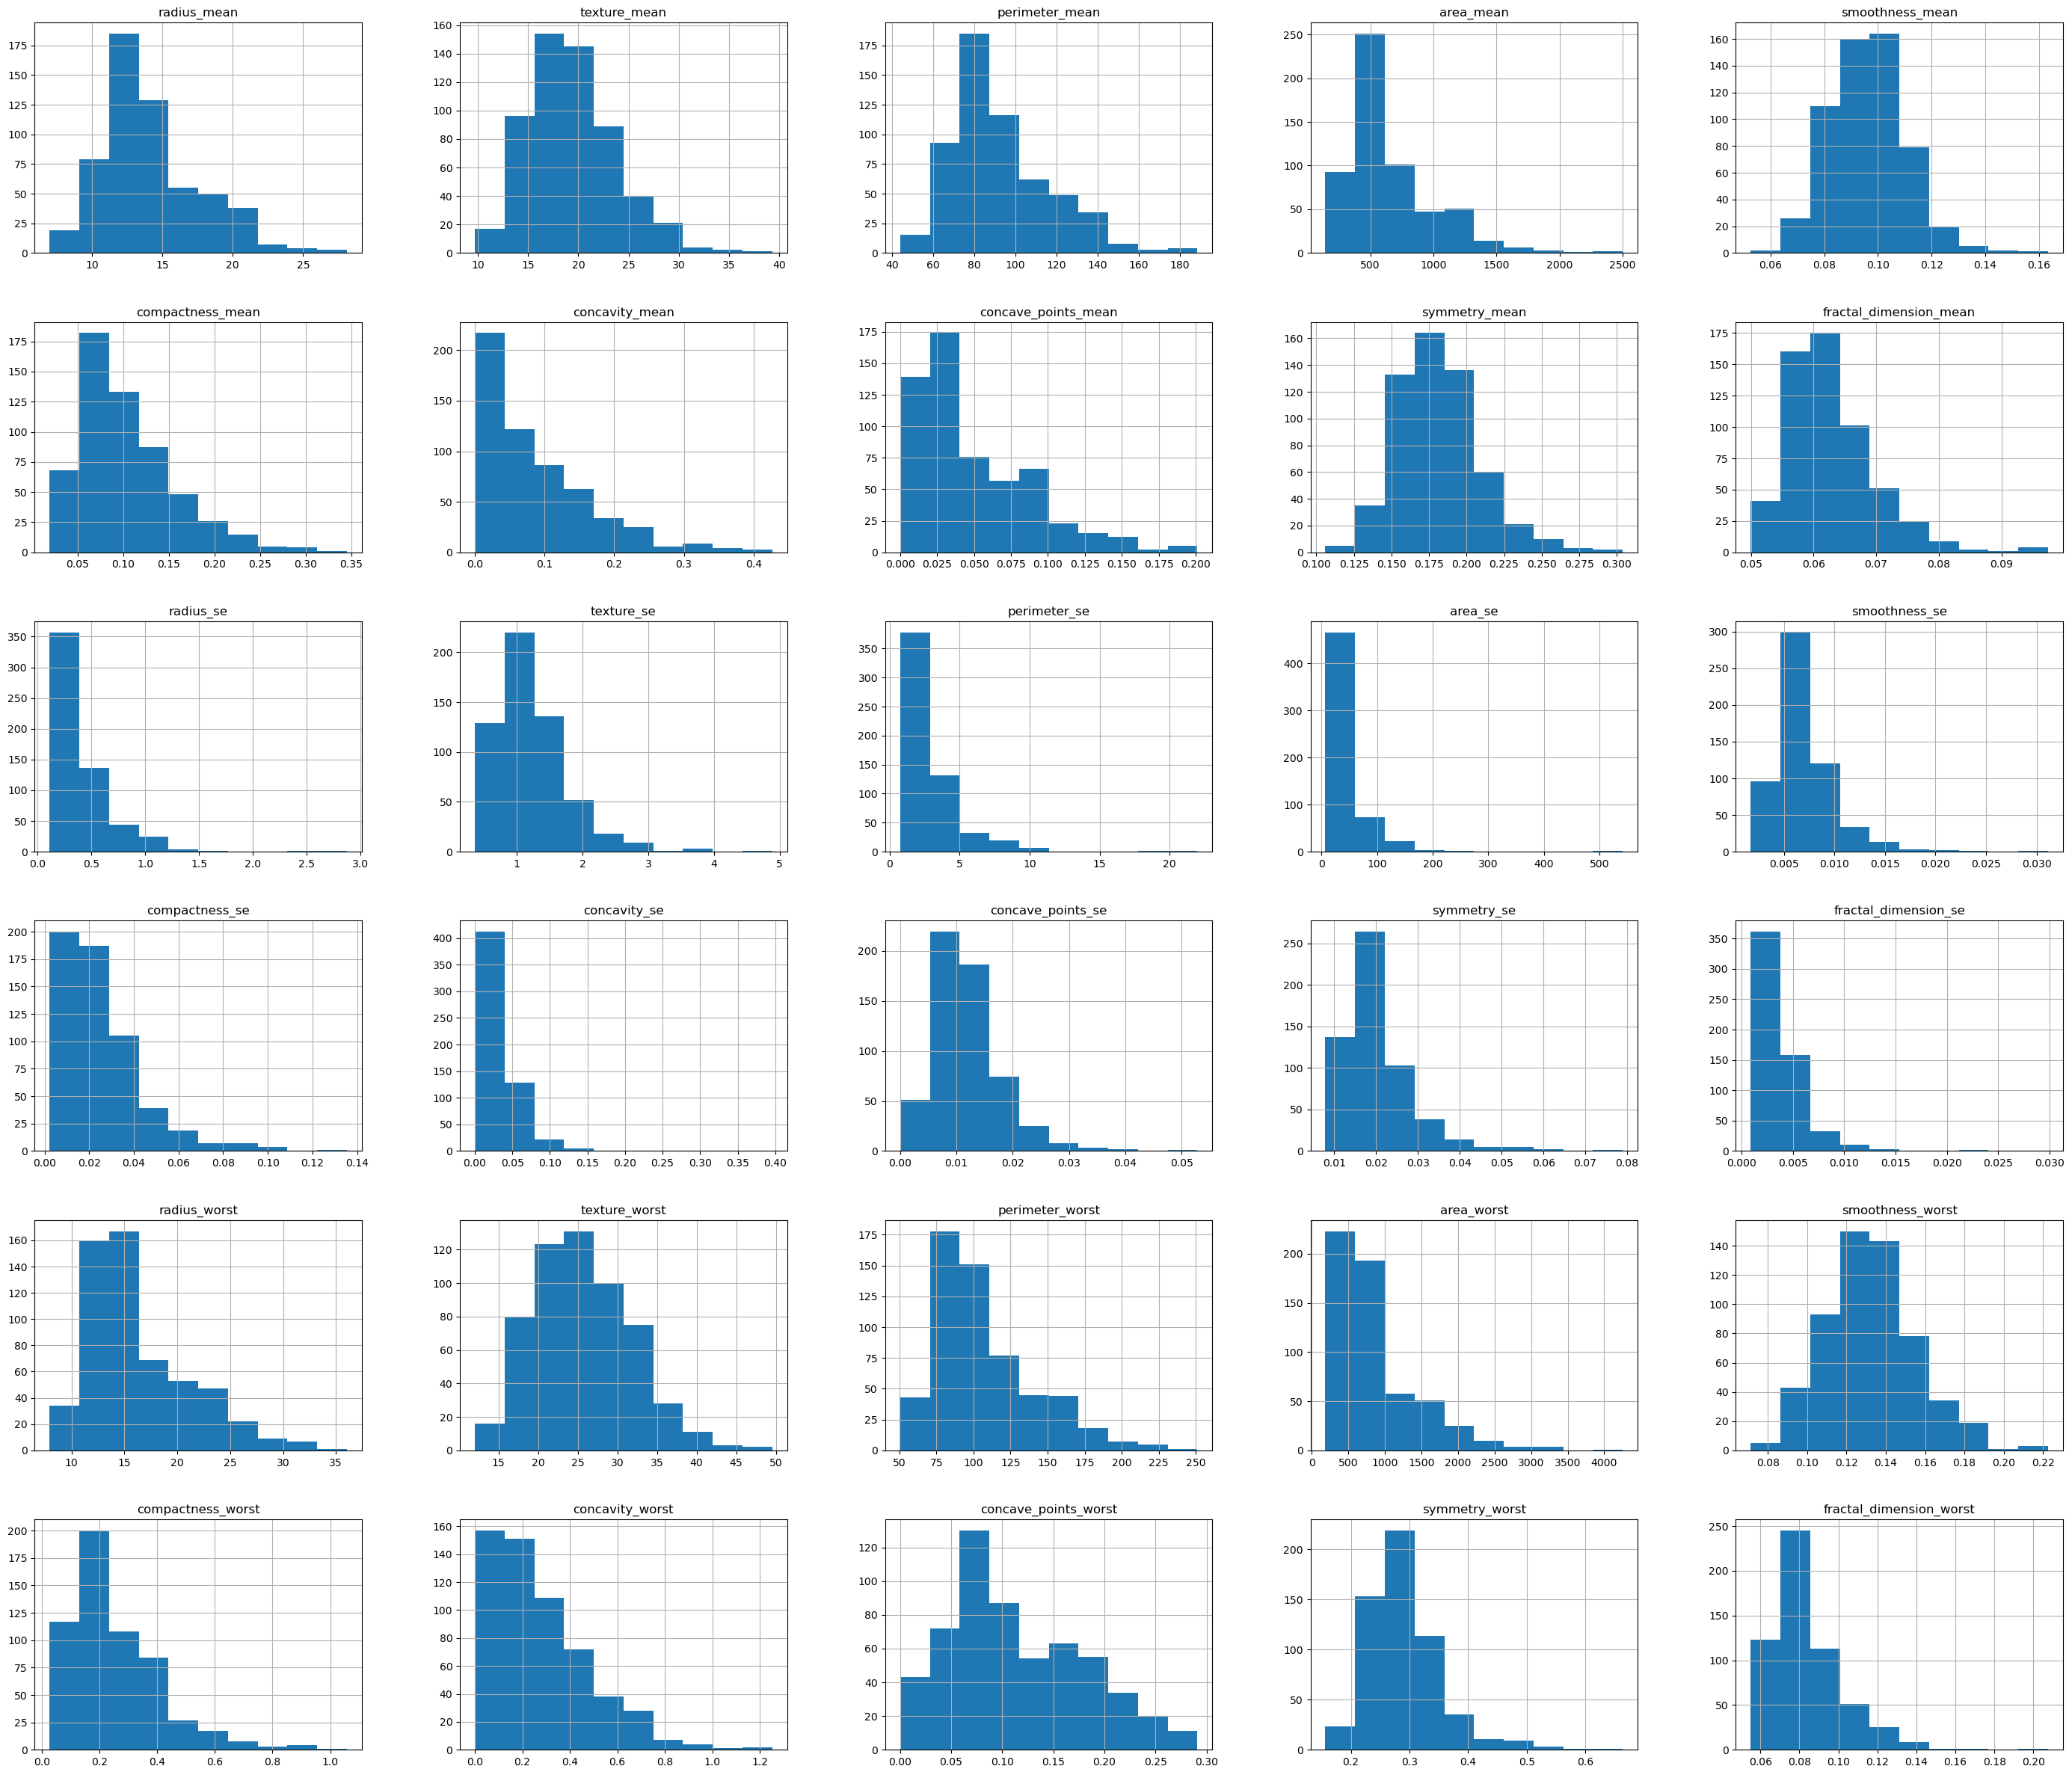

In [20]:
X.hist(figsize = (35,30))
plt.show()

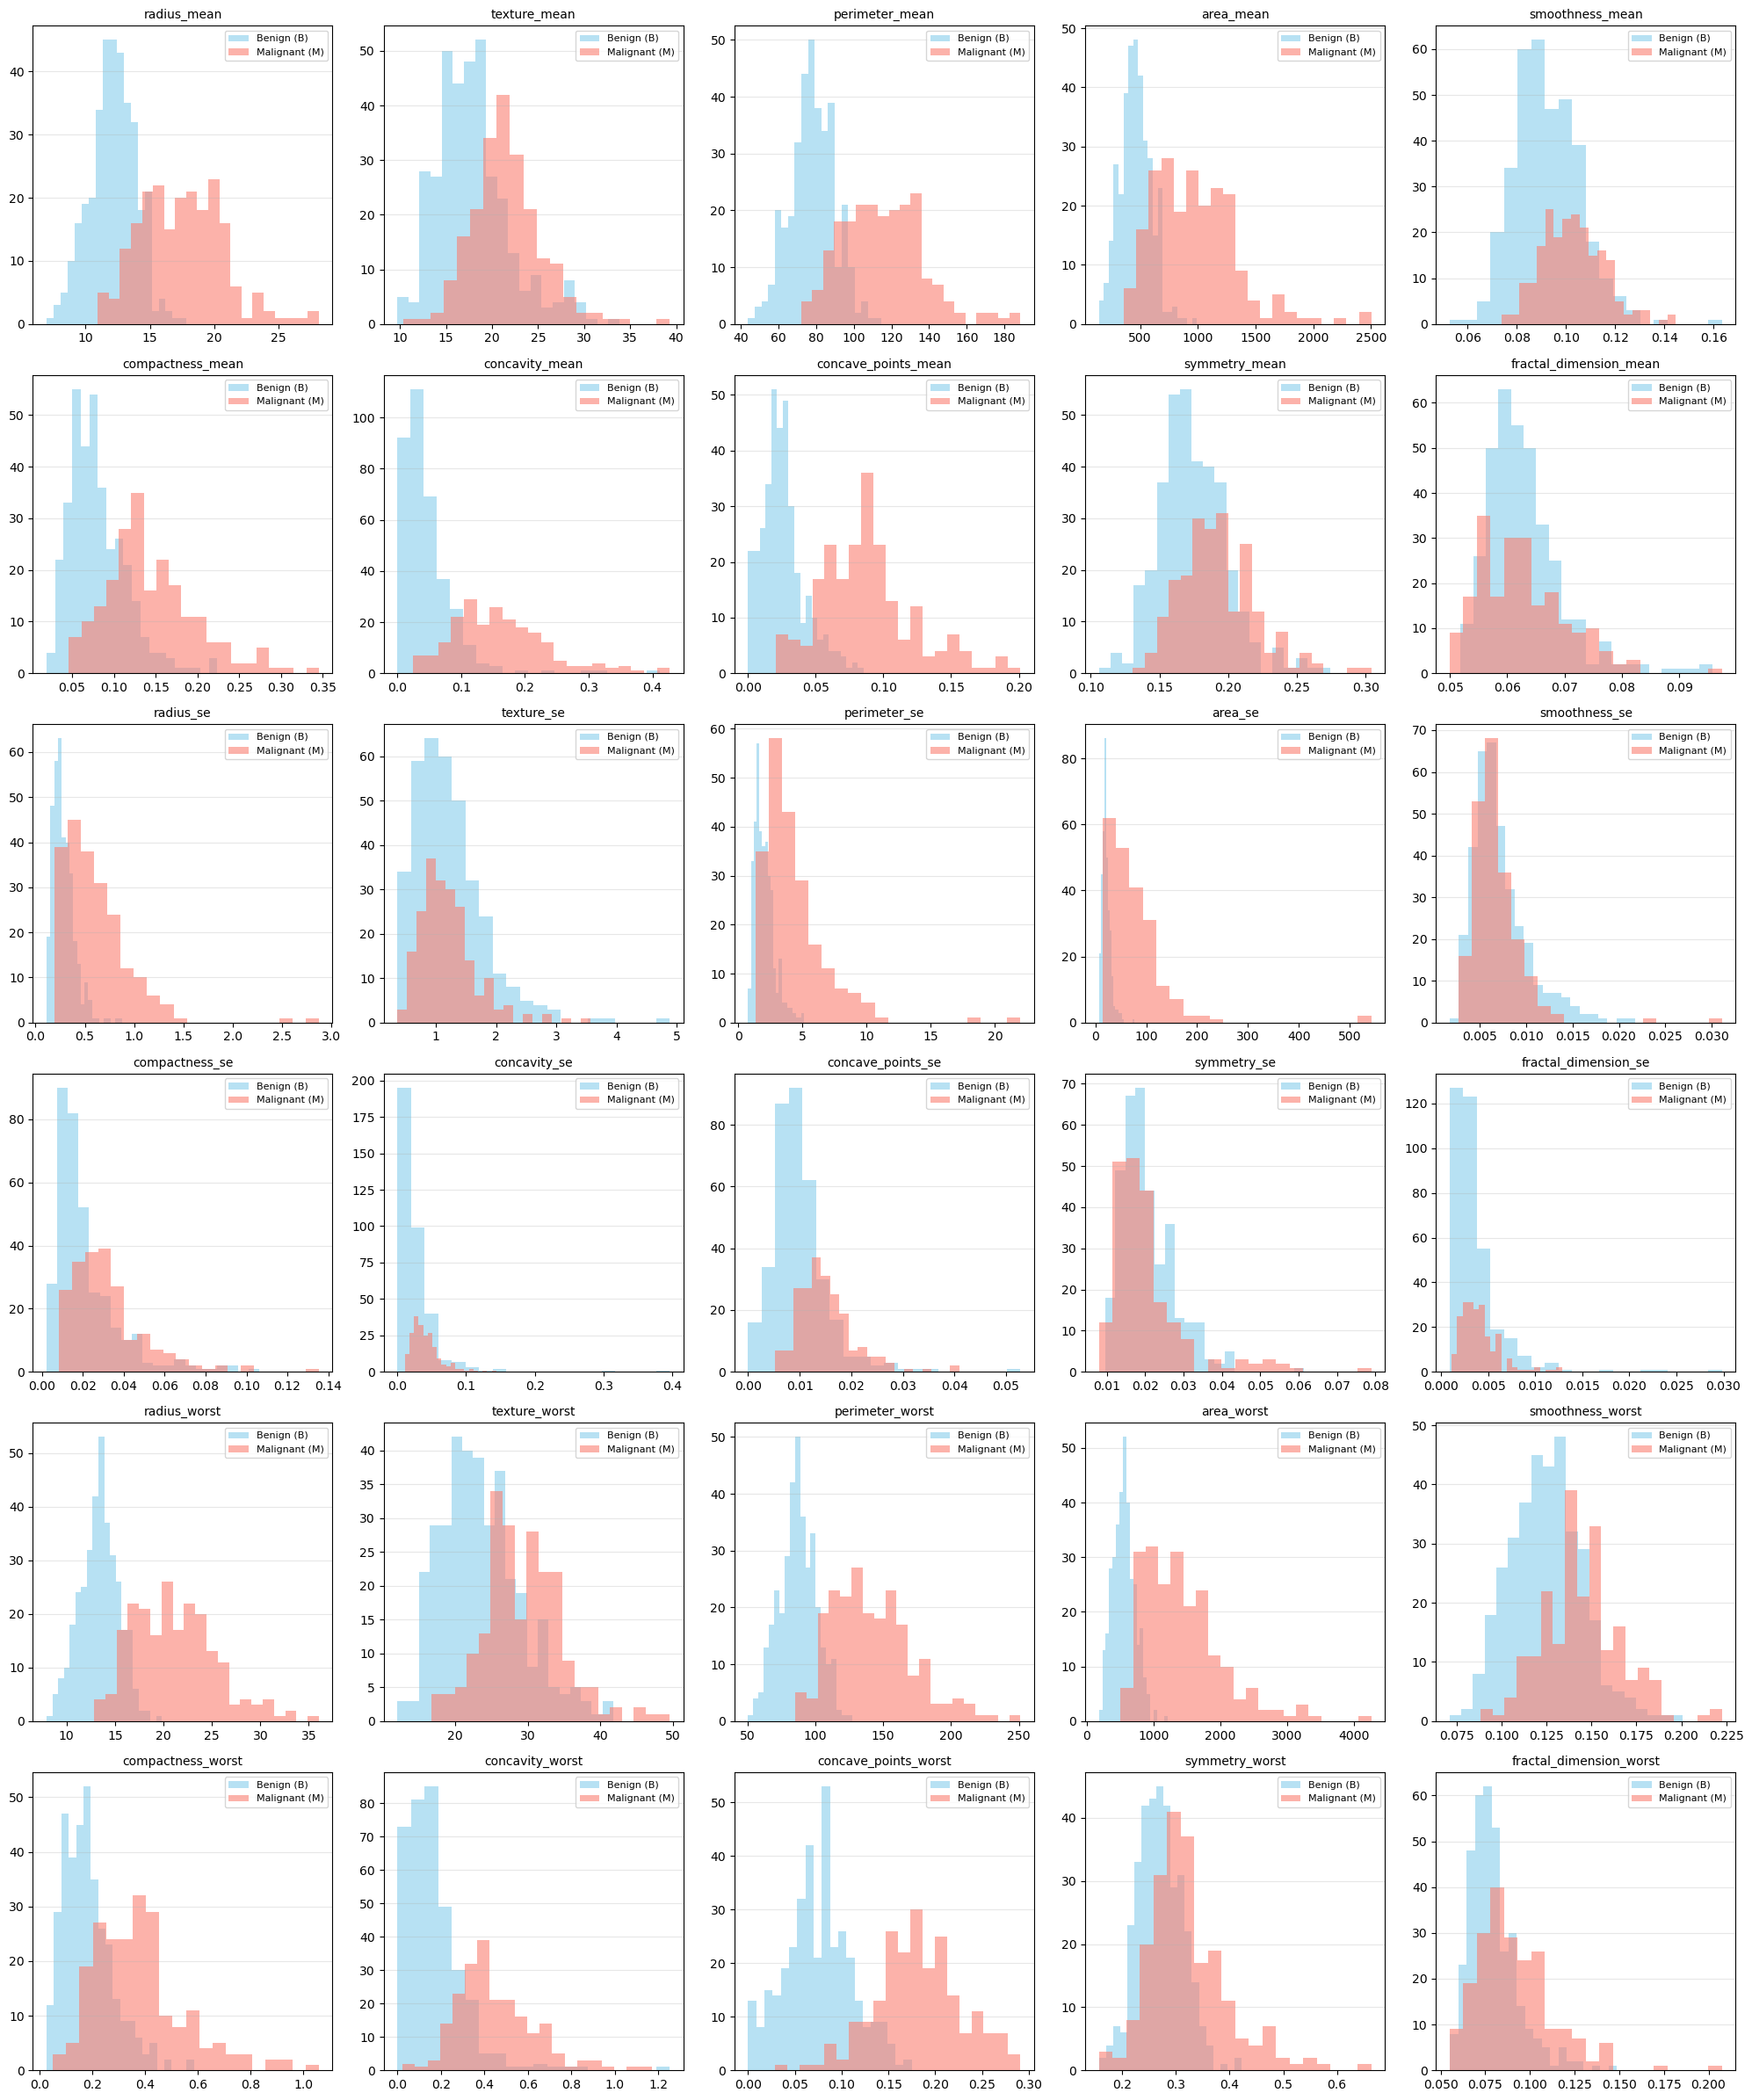

In [21]:
cols_per_row = 5
num_columns = len(X.columns)

fig, axes = plt.subplots(6, cols_per_row, figsize=(20, 4 * 6))
axes = axes.flatten()

for i, column in enumerate(X.columns):

    axes[i].hist(X[y == 0][column], bins=20, alpha=0.6, label='Benign (B)', color='skyblue')
    axes[i].hist(X[y == 1][column], bins=20, alpha=0.6, label='Malignant (M)', color='salmon')

    axes[i].set_title(f'{column}', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

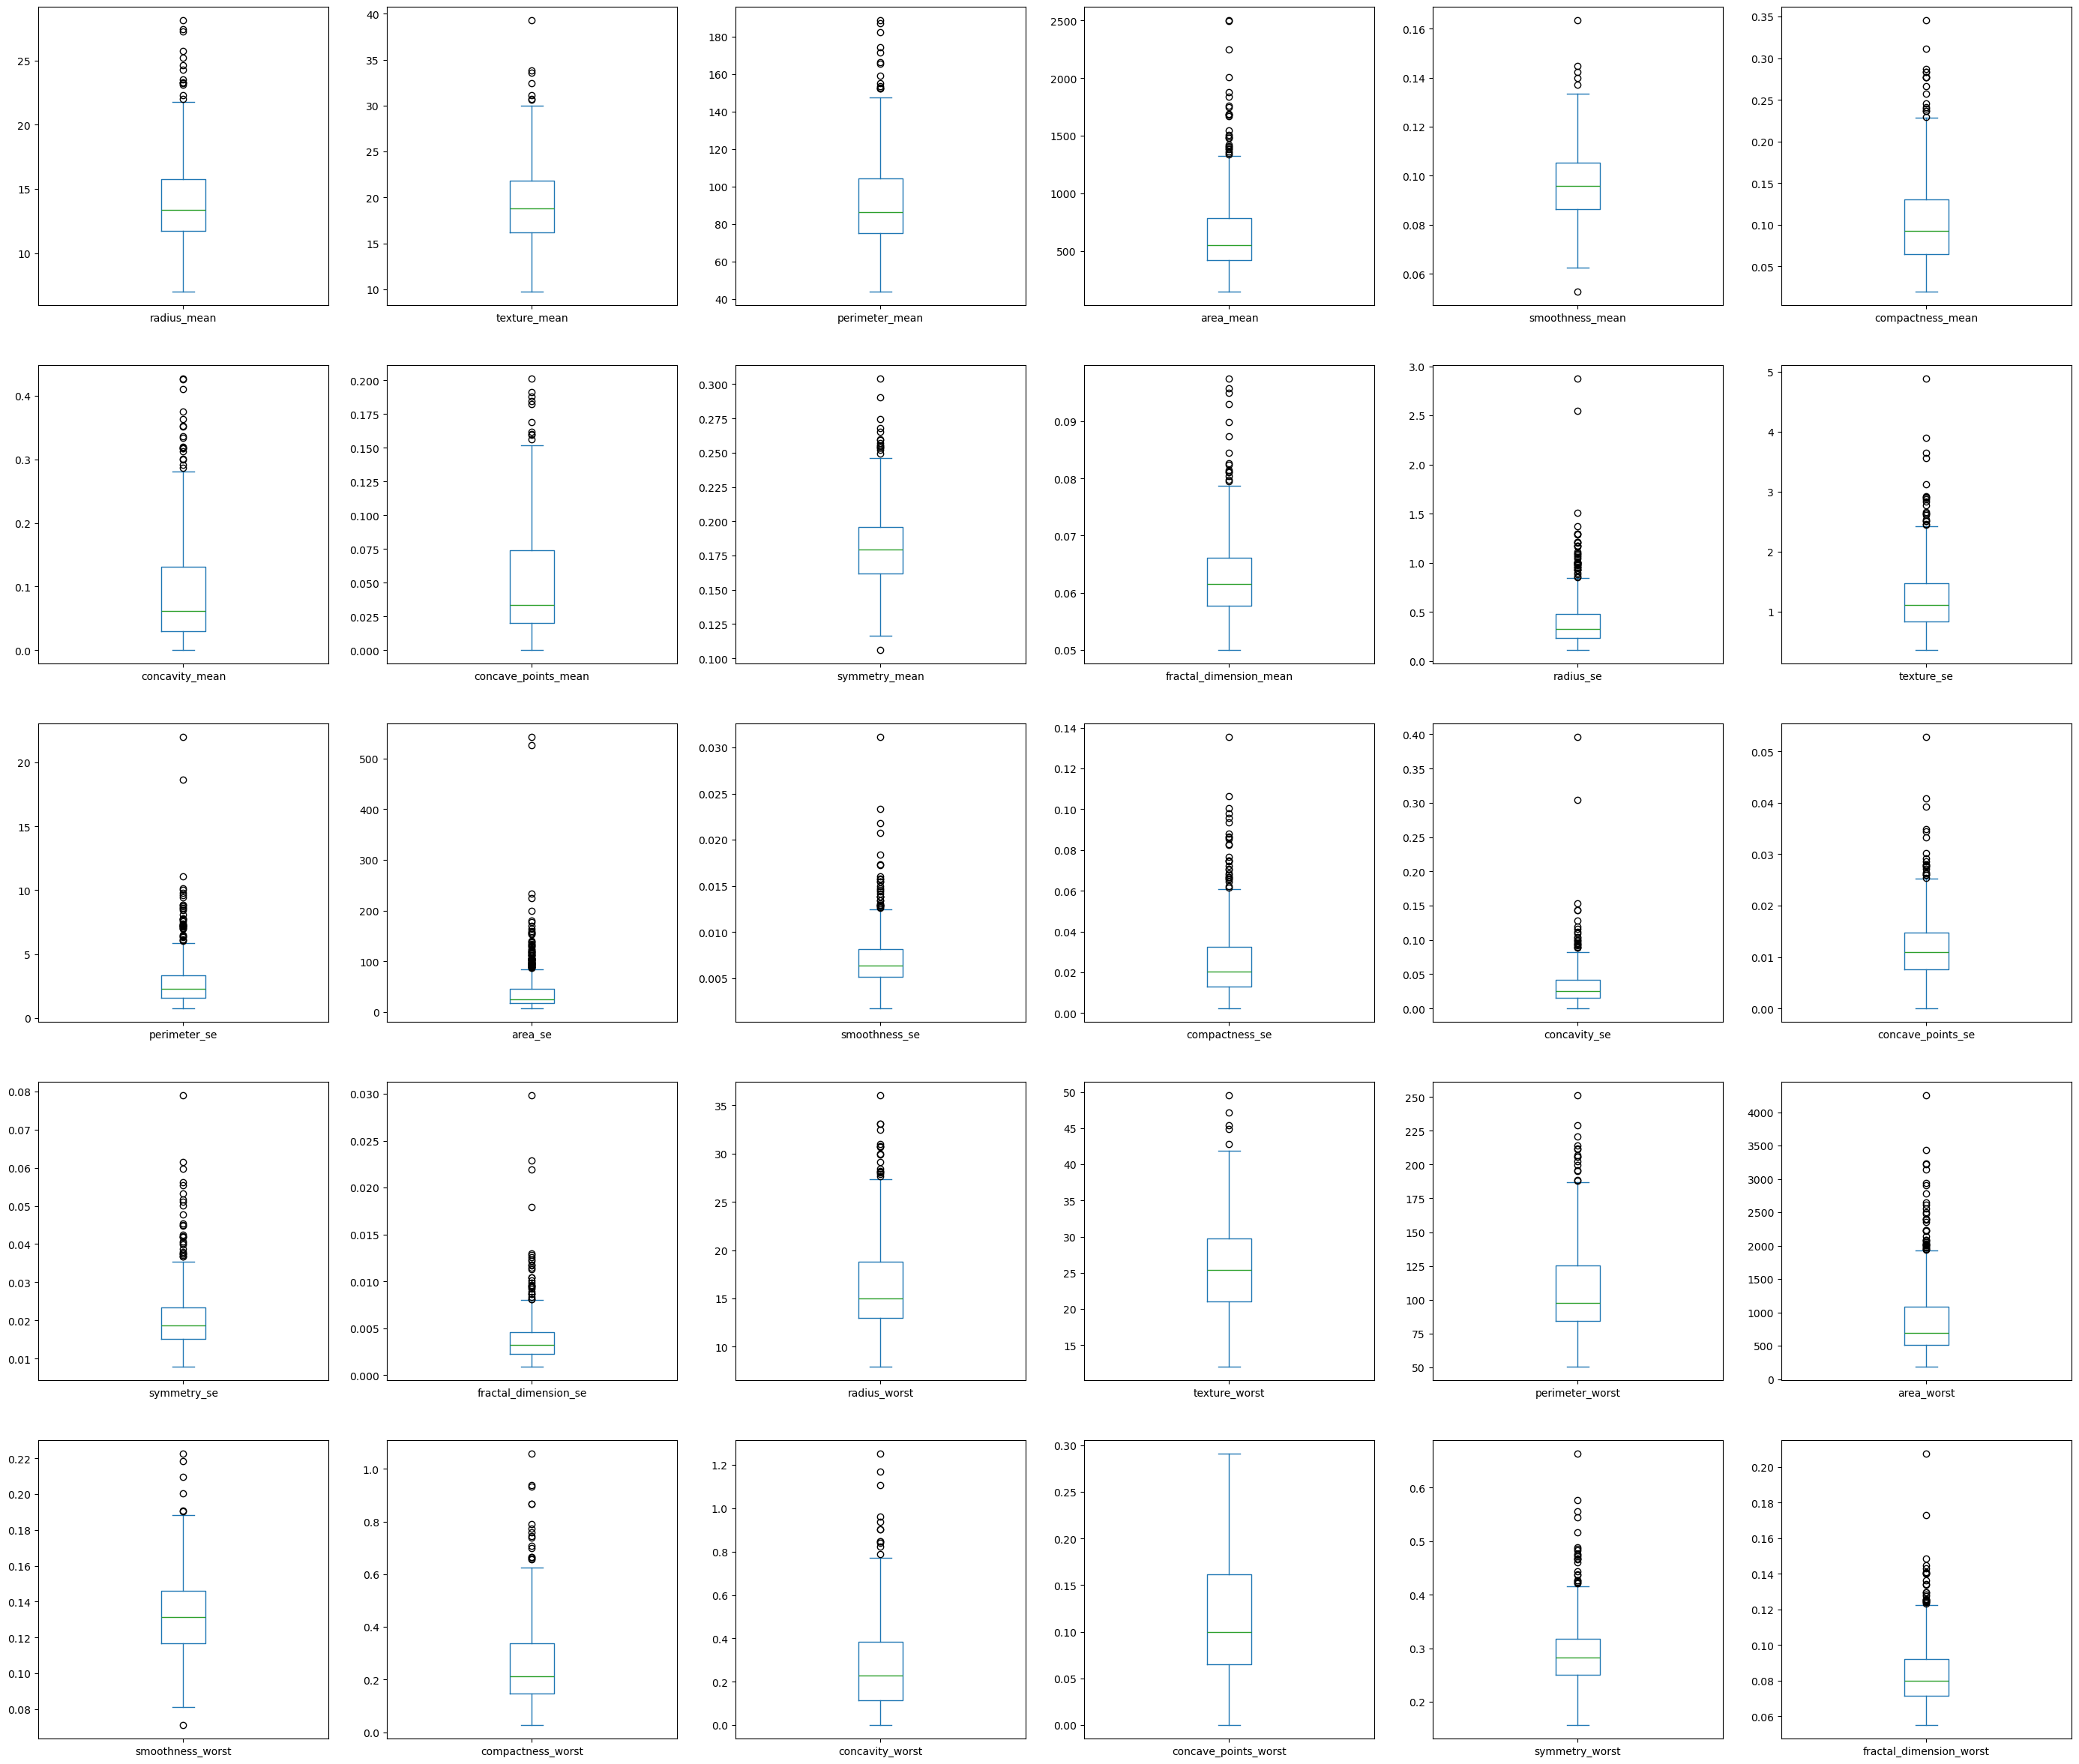

In [22]:
X.plot(kind='box', subplots=True, layout=(5, 6), figsize=(35, 30))
plt.show()

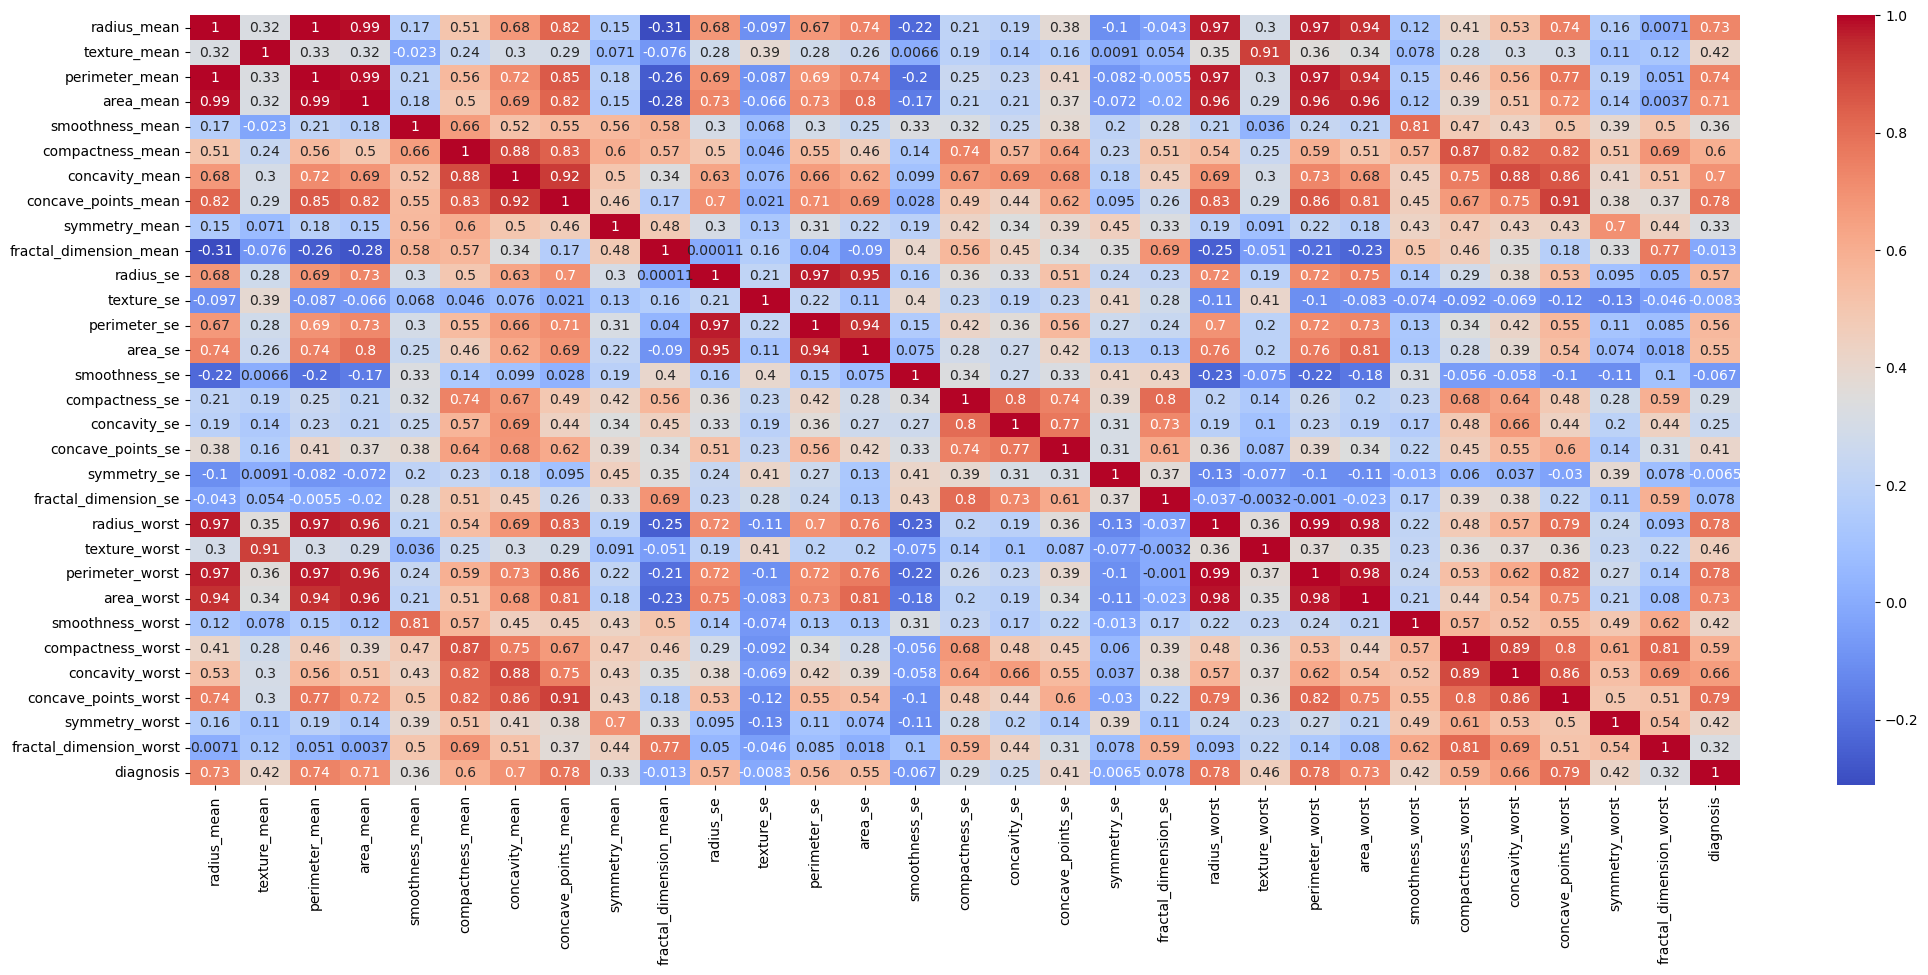

In [23]:
# Correlation heat map
corr = df.corr()
plt.figure(figsize=(25, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# Data Preparation and Feature Engineering


In [24]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, shuffle = True, stratify=y)


In [25]:
def handle_outliers_train_test(X_train, X_test):

    X_train_clean = X_train.copy()
    X_test_clean = X_test.copy()
    outlier_bounds = {}

    for column in X_train.columns:
        Q1 = X_train[column].quantile(0.25)
        Q3 = X_train[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_bounds[column] = {'lower': float(lower_bound),'upper': float(upper_bound)}

        outliers_train = ((X_train[column] < lower_bound) |
                         (X_train[column] > upper_bound)).sum()
        outliers_test = ((X_test[column] < lower_bound) |
                        (X_test[column] > upper_bound)).sum()

        X_train_clean[column] = X_train[column].clip(lower_bound, upper_bound)
        X_test_clean[column] = X_test[column].clip(lower_bound, upper_bound)

        if outliers_train > 0 or outliers_test > 0:
            print(f"{column}: Train outliers={outliers_train}, "
                  f"Test outliers={outliers_test}")


    return X_train_clean, X_test_clean, outlier_bounds

X_train, X_test, outlier_bounds = handle_outliers_train_test(X_train, X_test)

radius_mean: Train outliers=10, Test outliers=3
texture_mean: Train outliers=4, Test outliers=3
perimeter_mean: Train outliers=10, Test outliers=3
area_mean: Train outliers=18, Test outliers=5
smoothness_mean: Train outliers=4, Test outliers=2
compactness_mean: Train outliers=12, Test outliers=3
concavity_mean: Train outliers=15, Test outliers=3
concave_points_mean: Train outliers=12, Test outliers=5
symmetry_mean: Train outliers=12, Test outliers=4
fractal_dimension_mean: Train outliers=12, Test outliers=3
radius_se: Train outliers=27, Test outliers=10
texture_se: Train outliers=14, Test outliers=6
perimeter_se: Train outliers=29, Test outliers=9
area_se: Train outliers=46, Test outliers=18
smoothness_se: Train outliers=18, Test outliers=12
compactness_se: Train outliers=25, Test outliers=7
concavity_se: Train outliers=18, Test outliers=6
concave_points_se: Train outliers=18, Test outliers=6
symmetry_se: Train outliers=19, Test outliers=12
fractal_dimension_se: Train outliers=21, Test

In [26]:
# Scale
scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training



### Logistic Regression

In [27]:
def validate_model_kfold(model, param_dist, X_train, y_train, n_splits = 5, n_iter = 20):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=skf,
        scoring='f1',
        n_jobs=-1,
        verbose=1,
        random_state = 42
    )

    search.fit(X_train, y_train)

    # Fold-by-Fold accuracy
    best_index = search.best_index_
    print("\n")
    print("Each fold accuracy:")
    # Using F1 to test each fold's accuracy
    fold_scores = []
    for fold in range(n_splits):
        fold_score = search.cv_results_[f'split{fold}_test_score'][best_index]
        fold_scores.append(fold_score)
        print(f"Fold {fold + 1}: f1 = {fold_score * 100:.2f}%")

    print("\n")
    print(f"Best hyperparameter: {search.best_params_}")
    print(f"CV f1 score: {search.best_score_:.2%}")

    return search.best_estimator_, search.best_params_

In [28]:
param_dist_lr = {
    'penalty': ['l1','l2'],
    'solver': ['liblinear'],
    'C': [0.001,0.01,0.1],
    'class_weight':["balanced"]
}

logistic_regression_model, best_lr_params= validate_model_kfold(
    LogisticRegression(random_state = 42, max_iter= 1000),
    param_dist_lr,
    X_train_scaled,
    y_train)


Fitting 5 folds for each of 6 candidates, totalling 30 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=20. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(




Each fold accuracy:
Fold 1: f1 = 91.80%
Fold 2: f1 = 96.67%
Fold 3: f1 = 96.67%
Fold 4: f1 = 98.25%
Fold 5: f1 = 96.43%


Best hyperparameter: {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.1}
CV f1 score: 95.96%


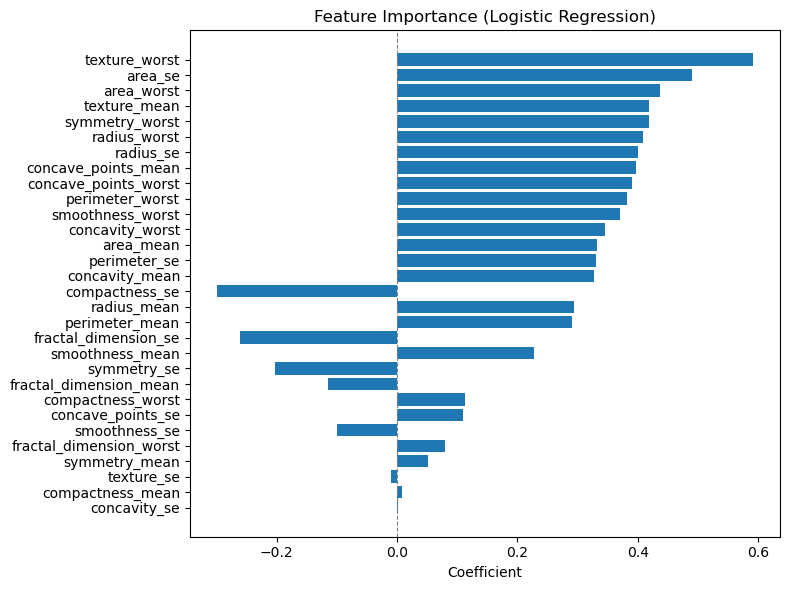

In [29]:
feature_names = np.array(X.columns)
coefs = logistic_regression_model.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))

plt.figure(figsize=(8, 6))
plt.barh(feature_names[sorted_idx], coefs[sorted_idx])
plt.axvline(0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Feature Importance (Logistic Regression)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

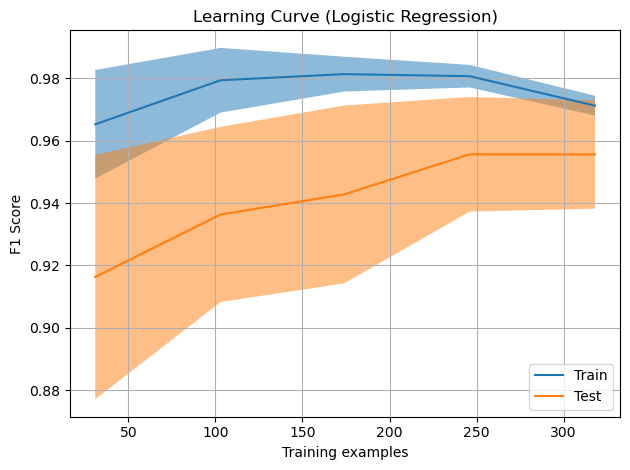

In [30]:
plt.figure(figsize=(8, 6))
display = LearningCurveDisplay.from_estimator(
    logistic_regression_model,
    X_train_scaled,
    y_train,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

plt.title("Learning Curve (Logistic Regression)")
plt.xlabel("Training examples")
plt.ylabel("F1 Score")
plt.grid(True)
plt.tight_layout()
plt.show()

Test F1 score: 99.21%

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       107
           1       1.00      0.98      0.99        64

    accuracy                           0.99       171
   macro avg       1.00      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



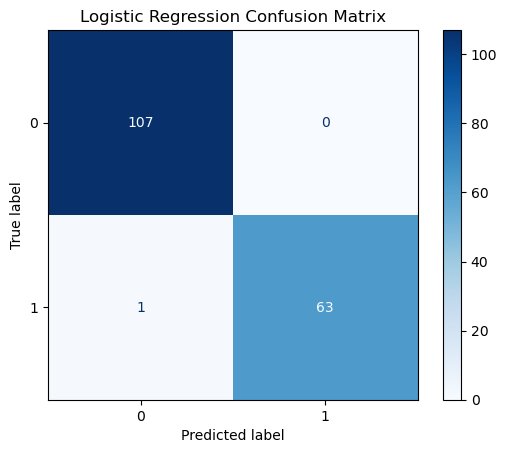

In [31]:
# Test model
y_pred = logistic_regression_model.predict(X_test_scaled)
test_f1 = f1_score(y_test, y_pred)
print(f"Test F1 score: {test_f1 * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### MLP

In [32]:
param_dist_mlp = {
    'hidden_layer_sizes': [
        (128,),
        (64, 32),
        (128, 64, 32),
        (128, 64, 32, 16),
        (256,128,64,64,32,16)],
    'activation': ['relu'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'early_stopping': [True]
}

mlp_model,best_mlp_params = validate_model_kfold(
    MLPClassifier(random_state=42, max_iter=1000),
    param_dist_mlp,
    X_train_scaled, y_train
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Each fold accuracy:
Fold 1: f1 = 96.67%
Fold 2: f1 = 98.31%
Fold 3: f1 = 96.67%
Fold 4: f1 = 98.25%
Fold 5: f1 = 96.55%


Best hyperparameter: {'solver': 'adam', 'learning_rate_init': 0.01, 'hidden_layer_sizes': (128, 64, 32), 'early_stopping': True, 'batch_size': 32, 'alpha': 0.1, 'activation': 'relu'}
CV f1 score: 97.29%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than s

<Figure size 800x600 with 0 Axes>

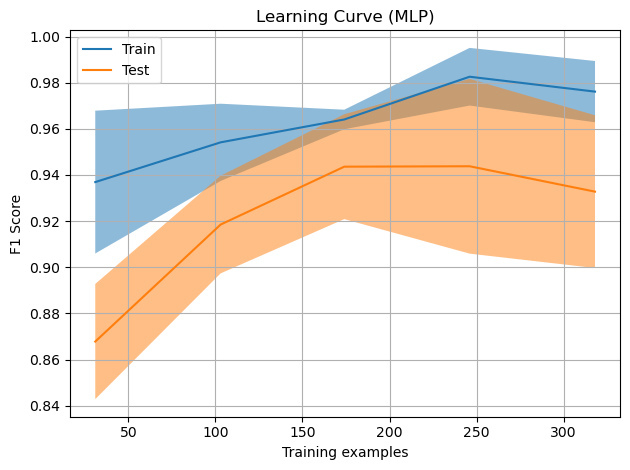

In [33]:
plt.figure(figsize=(8, 6))
display = LearningCurveDisplay.from_estimator(
    mlp_model,
    X_train_scaled,
    y_train,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

plt.title("Learning Curve (MLP)")
plt.xlabel("Training examples")
plt.ylabel("F1 Score")
plt.grid(True)
plt.tight_layout()
plt.show()

Early stopping at epoch 13


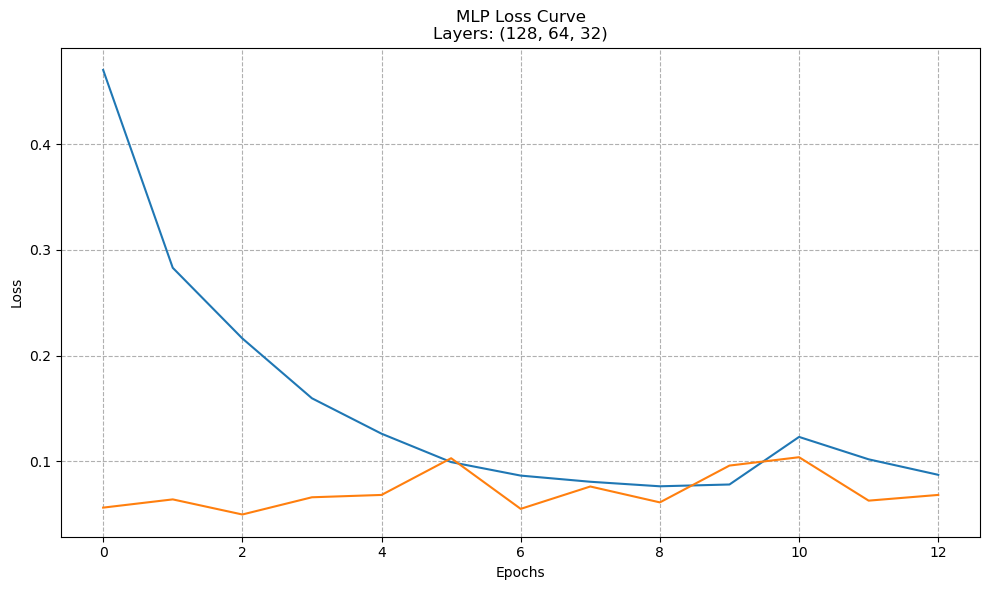

In [34]:
plot_params = best_mlp_params.copy()
plot_params['early_stopping'] = False

best_mlp_for_plot = MLPClassifier(
    **plot_params,
    warm_start=True,
    max_iter=1,
    random_state=42
)

train_losses = []
test_losses = []
epochs = 200
classes = np.unique(y_train)

best_test_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(epochs):
    best_mlp_for_plot.partial_fit(X_train_scaled, y_train, classes=classes)

    train_losses.append(best_mlp_for_plot.loss_)

    test_probs = best_mlp_for_plot.predict_proba(X_test_scaled)
    test_loss = log_loss(y_test, test_probs)
    test_losses.append(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title(f"MLP Loss Curve\nLayers: {best_mlp_params.get('hidden_layer_sizes')}")
plt.xlabel("Epochs",)
plt.ylabel("Loss")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Test F1 score: 96.88%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       107
           1       0.97      0.97      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



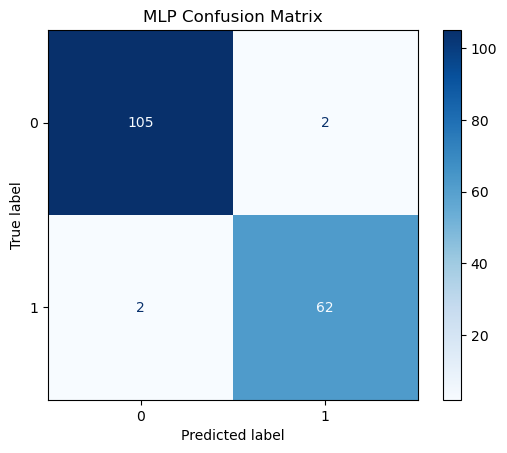

In [35]:
# Test model
y_pred = mlp_model.predict(X_test_scaled)
test_f1 = f1_score(y_test, y_pred)
print(f"Test F1 score: {test_f1 * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.show()